# Анализ НПА: недели 5–6
Продолжение `weeks_1_4.ipynb`. На 5-й неделе обучаются Word2Vec, fastText и учебная реализация GloVe. На 6-й строится прототип поиска похожих статей и PCA-визуализация. Подробные выводы находятся в `docs/coursework_weeks_5_6.md`.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import Image, display
from gensim.models import Word2Vec

ROOT = Path.cwd()
if not (ROOT / 'results').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from lawankz.coursework import preprocess_text
from lawankz.embeddings import (load_processed_articles, run_embeddings_analysis, search_by_vector)

INPUT = ROOT / 'results' / 'weeks_1_4'
OUT = ROOT / 'results' / 'weeks_5_6'
print('Проект:', ROOT)

Проект: C:\Users\danil\Documents\AIU\Обработка языков\LawanKZ


## Неделя 5 — Word2Vec, GloVe и fastText
Все модели обучаются на тех же 325 статьях и 45 924 леммах, с размерностью 100 и окном контекста 5. Word2Vec учит близость по локальным контекстам. GloVe использует глобальные количества совместных появлений. fastText дополнительно представляет слово через символьные n-граммы и поэтому может построить вектор для опечатки или новой формы.

Следующая ячейка полностью переобучает модели и занимает несколько минут. `workers=1` и фиксированный seed делают результат максимально повторяемым.

In [2]:
summary = run_embeddings_analysis(INPUT, OUT)
display(pd.DataFrame(summary['models']))
print('Статей:', summary['training_articles'], '| токенов:', summary['training_tokens'], '| размерность:', summary['vector_size'])

,model,vocabulary_size,evaluation_coverage,mean_association_cosine,mean_group_precision_at_5,oov_typo_supported
0,Word2Vec,1492,1.0,0.5859,0.2286,False
1,fastText,1492,1.0,0.5863,0.2429,True
2,GloVe,1492,1.0,0.7334,0.2714,False


Статей: 325 | токенов: 45924 | размерность: 100


`evaluation_coverage` — доля заранее выбранных юридико-тематических слов в словаре. `mean_association_cosine` — средний косинус для шести ожидаемо связанных пар. `mean_group_precision_at_5` — доля слов той же ручной тематической группы среди пяти соседей. Набор мал и служит диагностикой, а не стандартным benchmark. `oov_typo_supported` показывает, умеет ли модель получить вектор для отсутствующей формы `персональнвй`.

In [3]:
nearest = pd.read_csv(OUT / 'nearest_words.csv')
display(nearest[(nearest['query'].isin(['связь', 'интеллект', 'кибербезопасности'])) & (nearest['rank'] <= 5)])
display(pd.read_csv(OUT / 'vector_arithmetic.csv').query('rank <= 3'))

,model,query,rank,word,cosine
8,Word2Vec,связь,1,оператор,0.7612
9,Word2Vec,связь,2,сеть,0.6950
10,Word2Vec,связь,3,сотовый,0.6347
11,Word2Vec,связь,4,эксплуатировать,0.5773
12,Word2Vec,связь,5,услуга,0.5601
16,Word2Vec,интеллект,1,искусственный,0.9511
17,Word2Vec,интеллект,2,модель,0.5850
18,Word2Vec,интеллект,3,система,0.5790
19,Word2Vec,интеллект,4,синтетический,0.5172
20,Word2Vec,интеллект,5,способность,0.4665


,model,equation,rank,word,cosine
0,Word2Vec,персональный - данные + информация,1,нравственность,0.4243
1,Word2Vec,персональный - данные + информация,2,доступ,0.4156
2,Word2Vec,персональный - данные + информация,3,обладатель,0.4030
5,Word2Vec,оператор - связь + данные,1,персональный,0.4717
6,Word2Vec,оператор - связь + данные,2,собственник,0.4696
7,Word2Vec,оператор - связь + данные,3,восстановить,0.4455
10,Word2Vec,цифровой - среда + система,1,объект,0.5028
11,Word2Vec,цифровой - среда + система,2,искусственный,0.4533
12,Word2Vec,цифровой - среда + система,3,интеллект,0.4345
15,fastText,персональный - данные + информация,1,доступ,0.5081


Ближайшие слова дают понятные связи (`связь → оператор, сеть`; `интеллект → искусственный`). Векторная арифметика менее стабильна: корпус слишком мал, а юридические отношения не обязаны быть линейными. Поэтому эти примеры нельзя интерпретировать как логический вывод модели.

## Неделя 6 — поиск похожих статей
Статья представлена средним Word2Vec-вектором её лемм с весами IDF. Запрос проходит тот же препроцессинг. Результаты сортируются по косинусному сходству. Это семантический ранжировщик, но не юридическая консультация.

In [4]:
model = Word2Vec.load(str(OUT / 'word2vec.model')).wv
idf = json.loads((OUT / 'idf.json').read_text(encoding='utf-8'))
articles = load_processed_articles(OUT / 'search_articles.jsonl')
article_vectors = np.load(OUT / 'article_vectors.npy')
query = 'запрет обработки данных без согласия'
lemmas = preprocess_text(query)['lemmas']
results = search_by_vector(lemmas, model, idf, articles, article_vectors, top_k=5)
print('Запрос:', query, '| леммы:', lemmas)
display(pd.DataFrame(results)[['similarity', 'document_title', 'article_number', 'article_title', 'preview']])

Запрос: запрет обработки данных без согласия | леммы: ['запрет', 'обработка', 'без', 'согласие']


,similarity,document_title,article_number,article_title,preview
0,0.7440,О персональных данных и их защите,7,"Условия сбора, обработки персональных данных и...","1. Сбор, обработка персональных данных осущест..."
1,0.7351,О персональных данных и их защите,15,Распространение персональных данных,1. Распространение персональных данных допуска...
2,0.7063,О персональных данных и их защите,24,Права и обязанности субъекта,1. Субъект имеет право: 1) знать о наличии у с...
3,0.7060,Цифровой кодекс Республики Казахстан,40,Право на цифровую идентичность и ее защиту,1. Цифровая идентичность – совокупность цифров...
4,0.7002,О персональных данных и их защите,8,Порядок дачи (отзыва) согласия субъекта на сбо...,1. Субъект или его законный представитель дает...


In [5]:
metrics = json.loads((OUT / 'retrieval_metrics.json').read_text(encoding='utf-8'))
display(pd.DataFrame([metrics]))
print('Precision@5: доля соседей из того же акта. Hit rate@5: доля статей, для которых найден хотя бы один такой сосед.')

,article_count,top_k,precision_at_5,hit_rate_at_5,evaluation_note
0,325,5,0.6566,0.8831,"Запросом служит сама статья; она исключена, ре..."


Precision@5: доля соседей из того же акта. Hit rate@5: доля статей, для которых найден хотя бы один такой сосед.


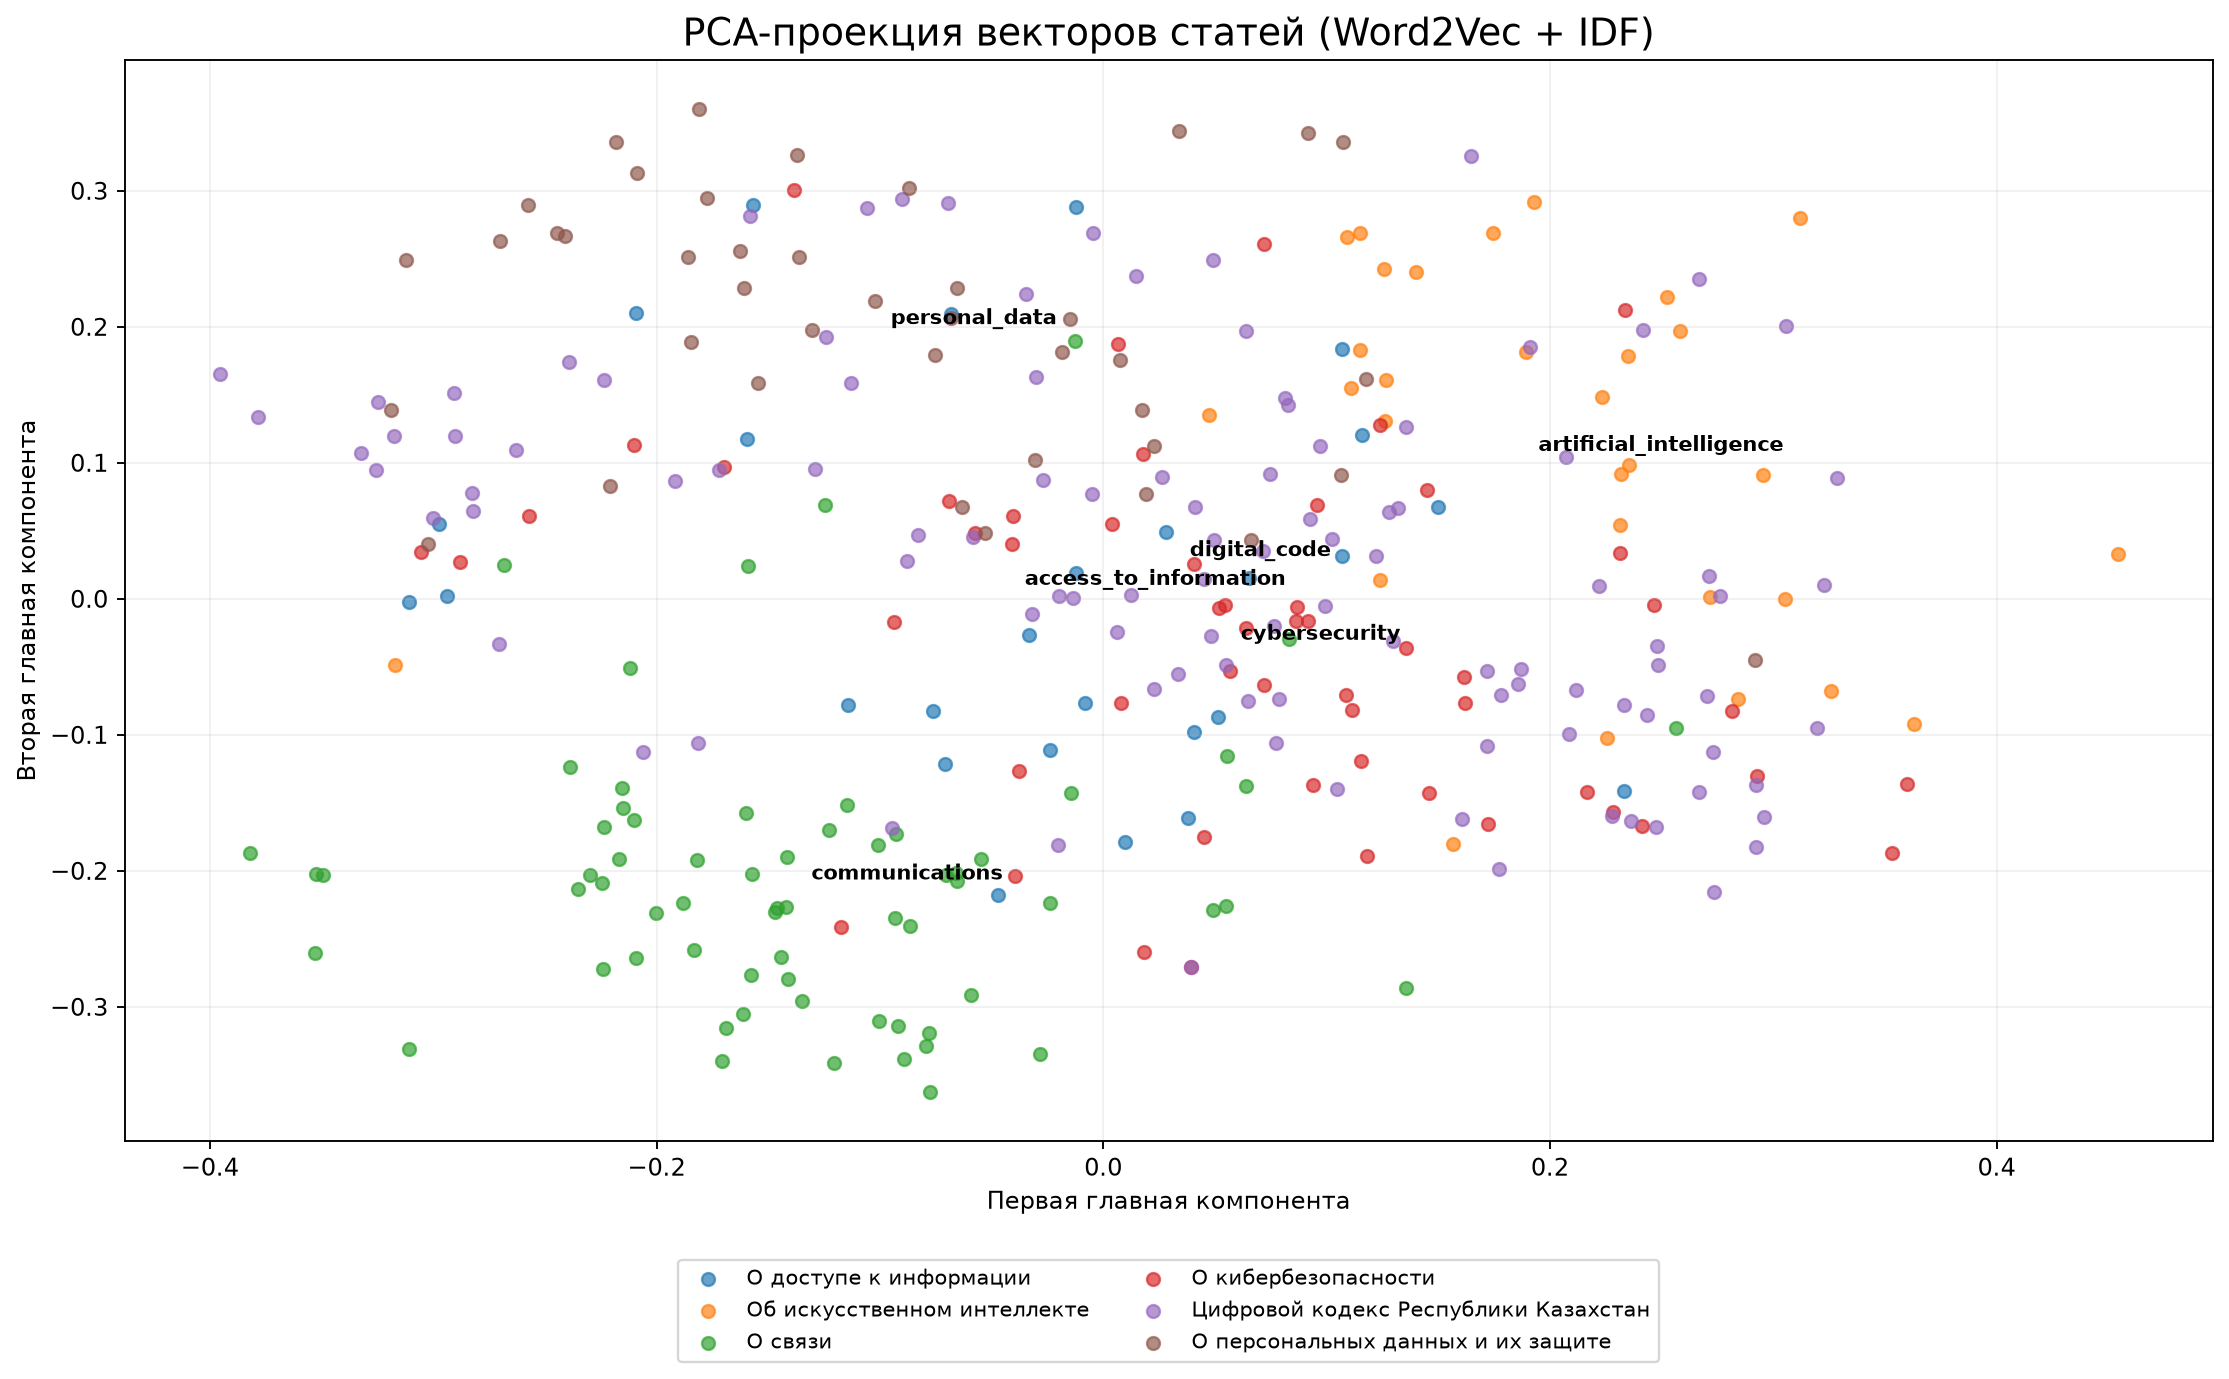

In [6]:
display(Image(filename=str(OUT / 'article_vectors_pca.png')))

### Вывод и ограничения
Поиск возвращает тематически подходящие статьи на пяти подготовленных запросах. Автооценка leave-one-out даёт precision@5 около 0,66 и hit rate@5 около 0,88, но считает релевантной любую статью того же акта — это упрощённая разметка. Для серьёзной оценки нужны запросы и ручные judgments эксперта. PCA показывает заметные зоны тематики связи, персональных данных и ИИ, однако двумерная картинка теряет большую часть 100-мерной информации.